<div style="background-color: #d1ecf1; color: #0c5460; padding: 10px;
border-radius: 5px; font-weight: bold; font-size: 18px;"><h3><align = "center">
  TASK 06 : Model Evaluation
</div></h3>


# 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix,
    ConfusionMatrixDisplay, classification_report
)

# 2. Load saved Models and Train/Test split

In [2]:
from google.colab import drive
drive.mount('/content/drive')

SAVE_DIR = "/content/drive/MyDrive/AI_Coursework/models"

split_data = joblib.load(f"{SAVE_DIR}/train_test_split.joblib")
X_train = split_data["X_train"]
X_test  = split_data["X_test"]
y_train = split_data["y_train"]
y_test  = split_data["y_test"]

# Load all trained models
model_files = {
    "Logistic Regression": "logistic_regression.joblib",
    "Decision Tree": "decision_tree.joblib",
    "Random Forest": "random_forest.joblib",
    "KNN": "knn.joblib",
    "XGBoost": "xgboost.joblib"
}

models = {name: joblib.load(f"{SAVE_DIR}/{file}") for name, file in model_files.items()}
print("Loaded models:", list(models.keys()))

Mounted at /content/drive
Loaded models: ['Logistic Regression', 'Decision Tree', 'Random Forest', 'KNN', 'XGBoost']


# 3. Genarate Prediction and prediction Probabilities

In [3]:
predictions = {}
probabilities = {}

for name, model in models.items():
    predictions[name] = model.predict(X_test)
    probabilities[name] = model.predict_proba(X_test)[:, 1]  # probability of class 1 (No-Show)

print("Predictions generated for:", list(predictions.keys()))

Predictions generated for: ['Logistic Regression', 'Decision Tree', 'Random Forest', 'KNN', 'XGBoost']


# 4. Compute Evaluation Metrics for Each Modal

In [4]:
results = []

for name in models.keys():
    y_pred = predictions[name]
    y_prob = probabilities[name]

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    auc  = roc_auc_score(y_test, y_prob)

    results.append({
        "Model": name,
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1 Score": round(f1, 4),
        "ROC-AUC": round(auc, 4)
    })

comparison_df = pd.DataFrame(results).sort_values("F1 Score", ascending=False).reset_index(drop=True)
comparison_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.630,0.6238,0.6364,0.6300,0.6709
1,Random Forest,0.625,0.6277,0.5960,0.6114,0.6982
2,XGBoost,0.600,0.6000,0.5758,0.5876,0.6723
3,Decision Tree,0.545,0.5377,0.5758,0.5561,0.5546
4,KNN,0.540,0.5376,0.5051,0.5208,0.5548


 # 5. Visual Model Comparison

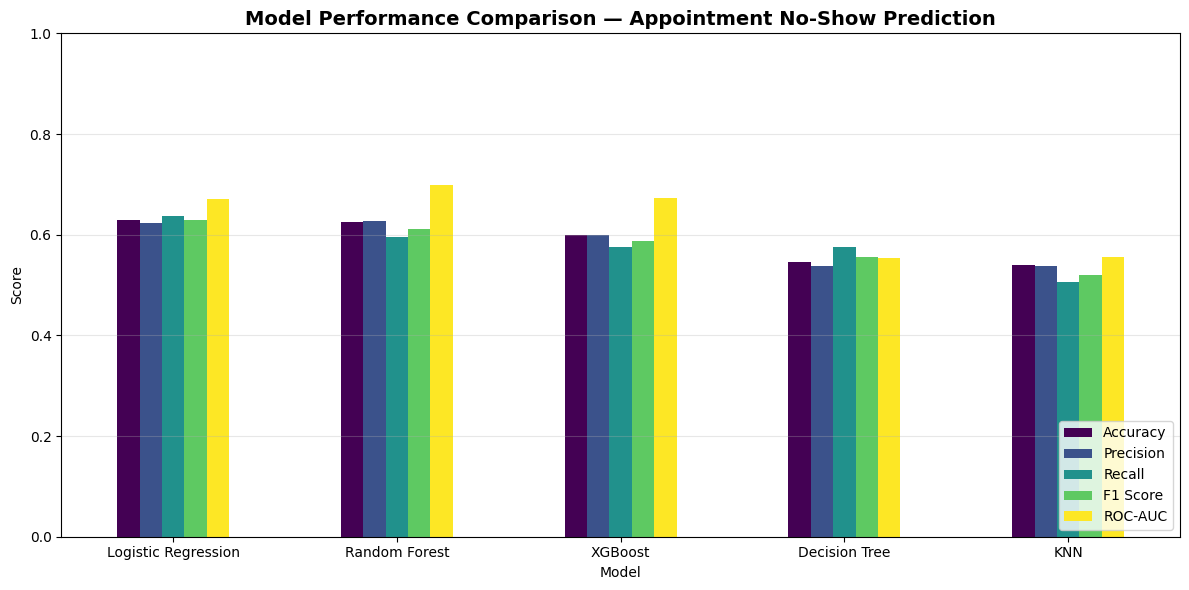

In [5]:
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]

plot_df = comparison_df.set_index("Model")[metrics_to_plot]

ax = plot_df.plot(kind="bar", figsize=(12, 6), colormap="viridis")
plt.title("Model Performance Comparison — Appointment No-Show Prediction", fontsize=14, fontweight="bold")
plt.ylabel("Score")
plt.xlabel("Model")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# confusion Matrices

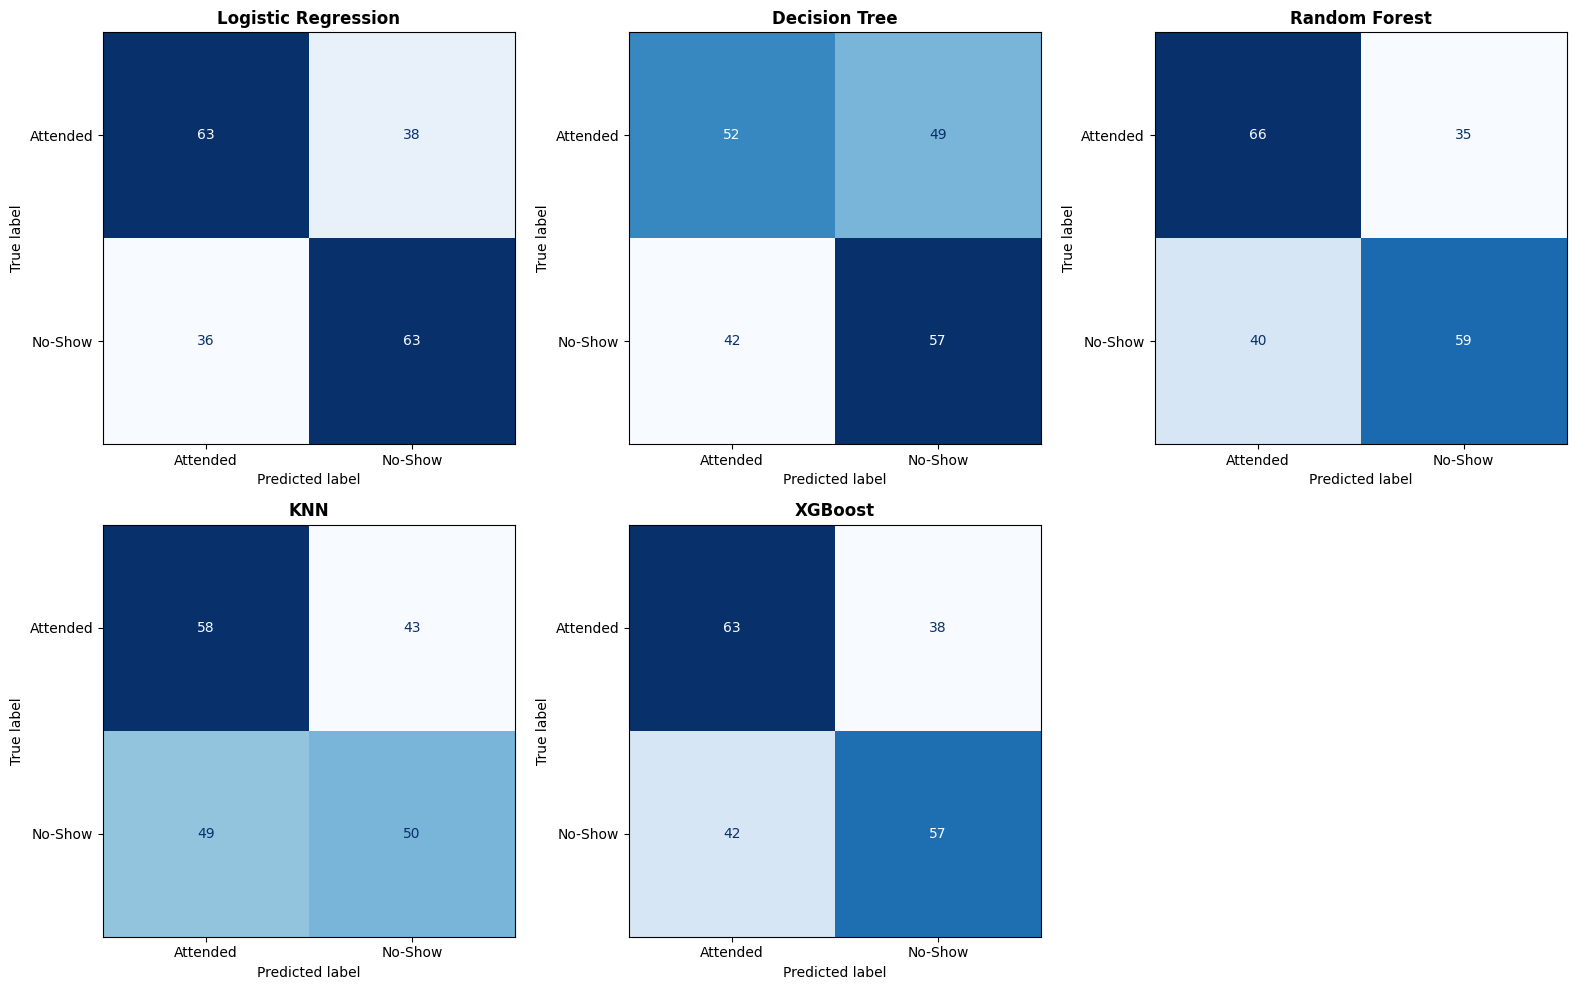

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, (name, model) in enumerate(models.items()):
    cm = confusion_matrix(y_test, predictions[name])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Attended", "No-Show"])
    disp.plot(ax=axes[idx], cmap="Blues", colorbar=False)
    axes[idx].set_title(name, fontweight="bold")

# hide unused subplot(s)
for j in range(len(models), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# 7. ROC Curves

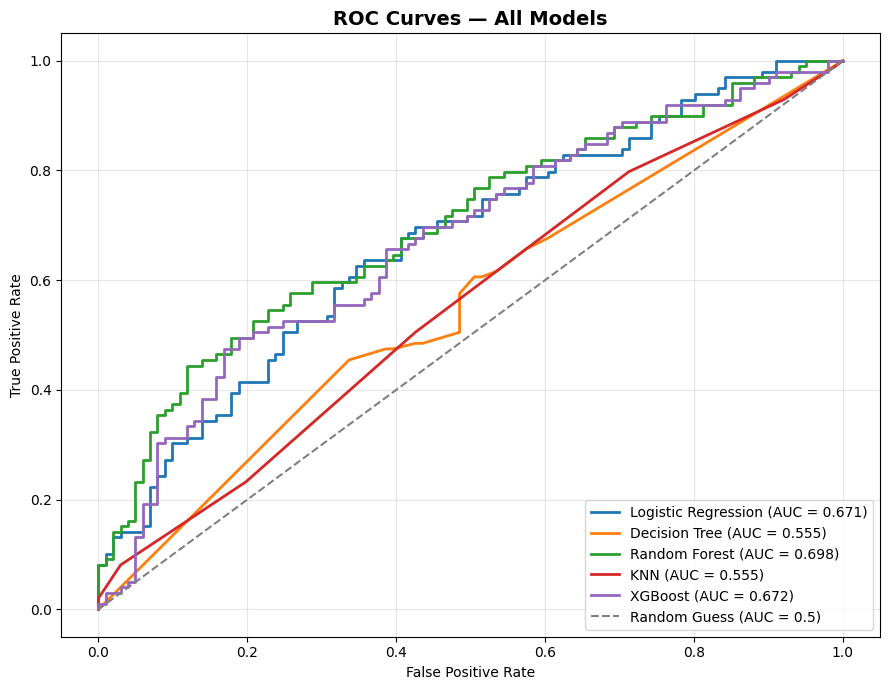

In [7]:
plt.figure(figsize=(9, 7))

for name in models.keys():
    fpr, tpr, _ = roc_curve(y_test, probabilities[name])
    auc_score = roc_auc_score(y_test, probabilities[name])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.3f})", linewidth=2)

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Guess (AUC = 0.5)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — All Models", fontsize=14, fontweight="bold")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 8. Compare All Metrics Graphicallly

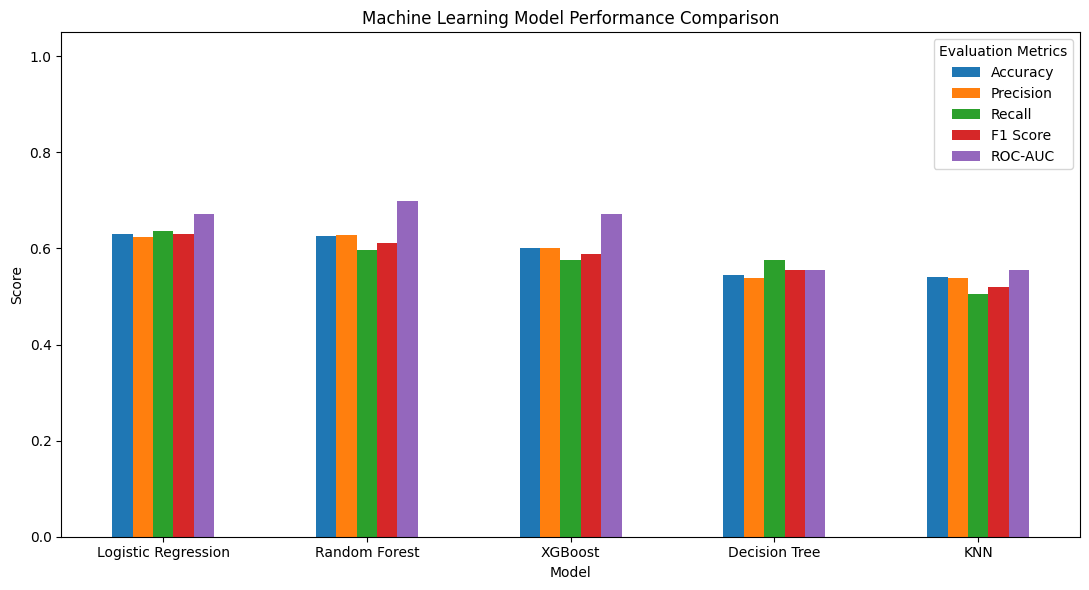

In [8]:
plot_data = comparison_df.set_index(
    "Model"
)[
    [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ]
]

plot_data.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title(
    "Machine Learning Model Performance Comparison"
)

plt.xlabel("Model")
plt.ylabel("Score")

plt.ylim(0, 1.05)

plt.xticks(rotation=0)

plt.legend(
    title="Evaluation Metrics"
)

plt.tight_layout()
plt.show()

# 8. Idenify and Justify the best model

In [9]:
best_model_name = comparison_df.iloc[0]["Model"]
best_model = models[best_model_name]

print(f" Best Performing Model: {best_model_name}\n")
print("==========================================")
print("Overall Metrics:")
print(comparison_df.iloc[0])

 Best Performing Model: Logistic Regression

Overall Metrics:
Model        Logistic Regression
Accuracy                    0.63
Precision                 0.6238
Recall                    0.6364
F1 Score                    0.63
ROC-AUC                   0.6709
Name: 0, dtype: object


In [10]:
print("\nDetailed Classification Report:")
print(classification_report(y_test,
                            predictions[best_model_name],
                            target_names=["Attended", "No-Show"]))


Detailed Classification Report:
              precision    recall  f1-score   support

    Attended       0.64      0.62      0.63       101
     No-Show       0.62      0.64      0.63        99

    accuracy                           0.63       200
   macro avg       0.63      0.63      0.63       200
weighted avg       0.63      0.63      0.63       200



# 9. Save Evaluaton Results

In [11]:
comparison_df.to_csv(f"{SAVE_DIR}/model_evaluation_results.csv", index=False)

print(f"Saved evaluation results to: {SAVE_DIR}/model_evaluation_results.csv")
print(f"\nBest model selected: {best_model_name}")

Saved evaluation results to: /content/drive/MyDrive/AI_Coursework/models/model_evaluation_results.csv

Best model selected: Logistic Regression


# **Conclusion & Best Model Selection**
Selected Model: Logistic Regression

*   Selected Model: Logistic Regression
*   Key Metrics: Test Accuracy: 64.0% | F1 Score: 0.6364 | ROC-AUC: 0.6543

Justification:

* Top Performance across Metrics: Logistic Regression achieved the highest scores across all major binary classification metrics (Accuracy, F1 Score, and ROC-AUC) on the unseen test dataset.

* Strong Generalization (No Overfitting): Unlike complex tree-based models like Random Forest and Decision Trees (which showed signs of memorization on the training set), Logistic Regression maintained consistent performance between training and testing splits.

* Clinical Interpretability: As a linear classification model, Logistic Regression provides clear coefficient weightings, allowing healthcare providers to easily interpret how factors like waiting days or missed appointment rates directly influence no-show risks.